# Voltix task3 _ Python 

Name : Alaa Ayman Ramadan    
Raw Data : Sample Superstore 2019 Dataset

Methods:
1. Import libraries , Check raw Data
2. Clean Data
3. Feature Engineering
4. EDA
5. Charts

## 0) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


colors = ["#8B2626", "#EF6905", "#F1E5A1", "#486C2F", "#DF301C"]
sns.set_palette(colors)

print("Libraries are successfuly imported")

Libraries are successfuly imported


## 1) Import and check raw data

In [2]:
try:
    df = pd.read_csv("employee_attrition.csv", encoding="utf-8")
    print("utf-8 is used")
except Exception as e:
    print("problem in reading file:", e)
print('#'*50)
print("Shape of Data:", df.shape)
print('#'*50)

utf-8 is used
##################################################
Shape of Data: (1470, 35)
##################################################


In [3]:
print('#'*50)
print('first 5 rows of raw data :')
print('#'*50)
pd.set_option('display.max_columns', None)
df.head(10)

##################################################
first 5 rows of raw data :
##################################################


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [4]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


1- businessProblem(target) --> Attrition (employee left the job ??) , over time 

2- personal employee details --> 7) age , distance from home , education , educationfield , gender ,marital status ,over 18

3- Details about department and job --> department ,job role ,job level , job involvement , business travel

4- salary&compensation --> monthly income, monthly rate,daily rate,hourly rate,percent salary hike,stock option level

5- experience --> total working hours,years with curr manager , YearsSinceLastPromotion,YearsInCurrentRole,YearsAtCompany,NumCompaniesWorked

6- satisfaction & performance --> EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,PerformanceRating

## 2) check data if it needs to be cleaned

In [5]:
print('#'*50)
print('information about raw data :')
print('#'*50)
df.info()

##################################################
information about raw data :
##################################################
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                

In [6]:
print("#"*50)
print("Duplicate Rows:")
print("#"*50)
duplicated_number= df.duplicated().sum()
print(f'We have mumber of {duplicated_number} duplicates')

##################################################
Duplicate Rows:
##################################################
We have mumber of 0 duplicates


no missing values , no inconsistent of data types  , no duplication

In [7]:
def eda_function(df):
    print("#"*50)
    print("Object Statistics:")
    print("#"*50)
    print(df.describe(include=["object",'str']))
    print("#"*50)
    print("Numerical Statistics:")
    print("#"*50)
    print(df.describe())
    return df

In [8]:
eda_function(df.head(2))

##################################################
Object Statistics:
##################################################
       Attrition BusinessTravel Department EducationField  Gender  \
count          2              2          2              2       2   
unique         2              2          2              1       2   
top          Yes  Travel_Rarely      Sales  Life Sciences  Female   
freq           1              1          1              2       1   

                JobRole MaritalStatus Over18 OverTime  
count                 2             2      2        2  
unique                2             2      1        2  
top     Sales Executive        Single      Y      Yes  
freq                  1             1      2        1  
##################################################
Numerical Statistics:
##################################################
             Age    DailyRate  DistanceFromHome  Education  EmployeeCount  \
count   2.000000     2.000000          2.000000   2.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7


In [9]:
df["EmployeeNumber"].nunique() # all eployees have unique id

1470

In [10]:
def get_column_types(df):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object','str']).columns.tolist()

    print("Numeric Columns:")
    print(numeric_cols)

    print("\nCategorical Columns:")
    print(categorical_cols)

In [11]:
get_column_types(df)

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [12]:
df['Attrition'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [13]:
df['Department'].unique()

<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

In [14]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [15]:
df['Over18'].unique()

<StringArray>
['Y']
Length: 1, dtype: str

In [16]:
df['OverTime'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [17]:
df['MaritalStatus'].unique()

<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

In [18]:
df['JobRole'].unique()

<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

In [19]:
df['BusinessTravel'].unique()

<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

In [20]:
df['EducationField'].unique()

<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

data is clear no need to clean 

## 3) Feature Engineering (EDA)

In [21]:
df["Attrition"].value_counts() # 237 employee left 

Attrition
No     1233
Yes     237
Name: count, dtype: int64

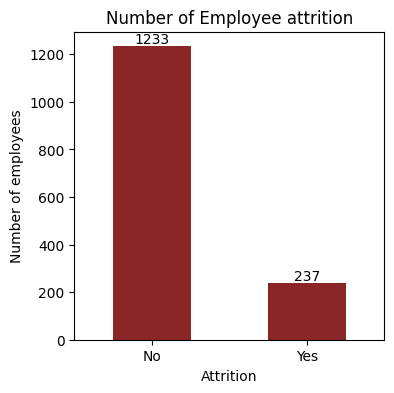

In [22]:
#  237 employee left from all departments   problem here???
attrition_counts = df["Attrition"].value_counts()
plt.figure(figsize=(4, 4))
ax = attrition_counts.plot(kind="bar", color=colors[0])
ax.bar_label(ax.containers[0])
plt.title("Number of Employee attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of employees")
plt.xticks(rotation=0) # (x_axis horizontal)
plt.show()

In [23]:
attrition_rate = (df["Attrition"] == 'Yes') .mean()*100

print(f'attrition rate of all departments : {attrition_rate:.1f}%')

attrition rate of all departments : 16.1%


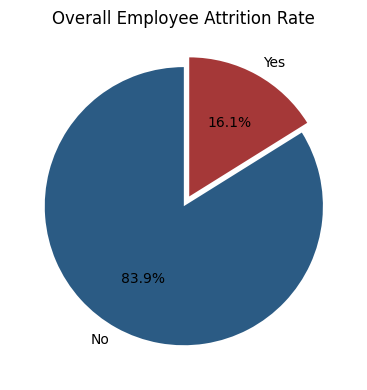

In [24]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    attrition_counts,
    labels=attrition_counts.index,  
    autopct="%1.1f%%",  
    startangle=90,
    colors=["#2B5B84", "#A53838"], 
    explode=(0, 0.08),
)
plt.title("Overall Employee Attrition Rate")
plt.tight_layout()
plt.show()

# 4) visualization

 department then job role
 
 │
 
 ├── OverTime
 
 ├── Job Satisfaction
 
 ├── Work-Life Balance
 
 ├── Monthly Income
 
 ├── Years at Company
 
 ├── Performance Rating
 
 └── Age / etc.

## Target why 237 has left the company ?????


##  تحليل الموظفين حسب الأقسام والوظائف


### we need to calc attrition rate as no.employees is different in every department

In [25]:
department_counts = df['Department'].value_counts()
department_counts

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

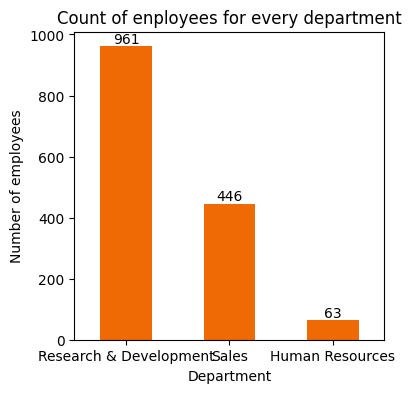

In [26]:
# R&D most employees
plt.figure(figsize=(4, 4))
ax1 = department_counts.plot(kind="bar", color=colors[1])
ax1.bar_label(ax1.containers[0])
plt.title("Count of enployees for every department")
plt.xlabel("Department")
plt.ylabel("Number of employees")
plt.xticks(rotation=0) # (x_axis horizontal)
plt.show()

In [27]:
pd.crosstab(df['Department'],df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [28]:
# sales has most > HR > RS
# attrition rate by department
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize = 'index'
) * 100

dept_attrition_yes=department_attrition['Yes'].sort_values(ascending=False).round(1)
dept_attrition_yes

Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Yes, dtype: float64

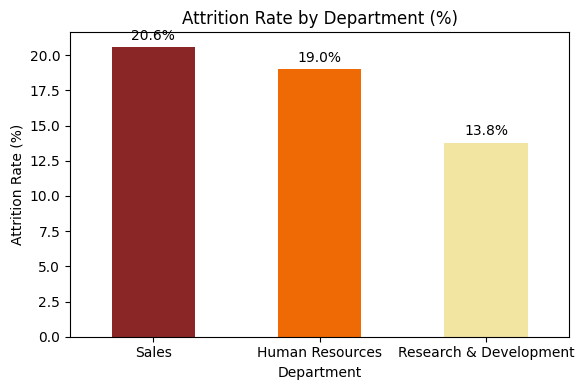

In [29]:
plt.figure(figsize=(6, 4))
ax = dept_attrition_yes.plot(kind="bar", color=colors)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.title("Attrition Rate by Department (%)")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

the department sales has highest attrition rate we will require further investigation  yo identify reason

### we need to calc attrition rate as no.employees is different in every JobRole

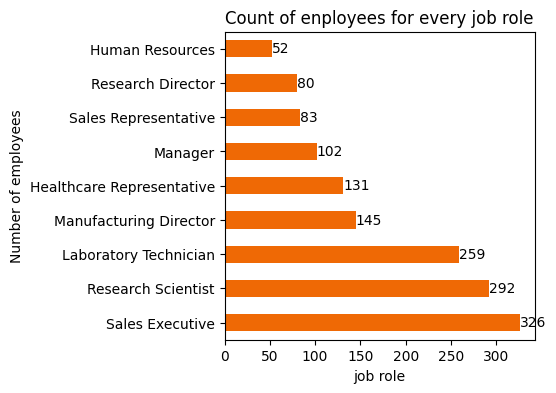

In [30]:
plt.figure(figsize=(4, 4))
jobrole_count=df['JobRole'].value_counts()
ax = jobrole_count.plot(kind="barh", color=colors[1])
ax.bar_label(ax.containers[0])
plt.title("Count of enployees for every job role")
plt.xlabel("job role")
plt.ylabel("Number of employees")
plt.xticks(rotation=0) 
plt.show()

In [31]:
# sales has most > HR > RS
# attrition rate by department
department_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize = 'index'
) * 100

job_attrition_yes=department_attrition['Yes'].sort_values(ascending=False).round(1)
job_attrition_yes

JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5
Name: Yes, dtype: float64

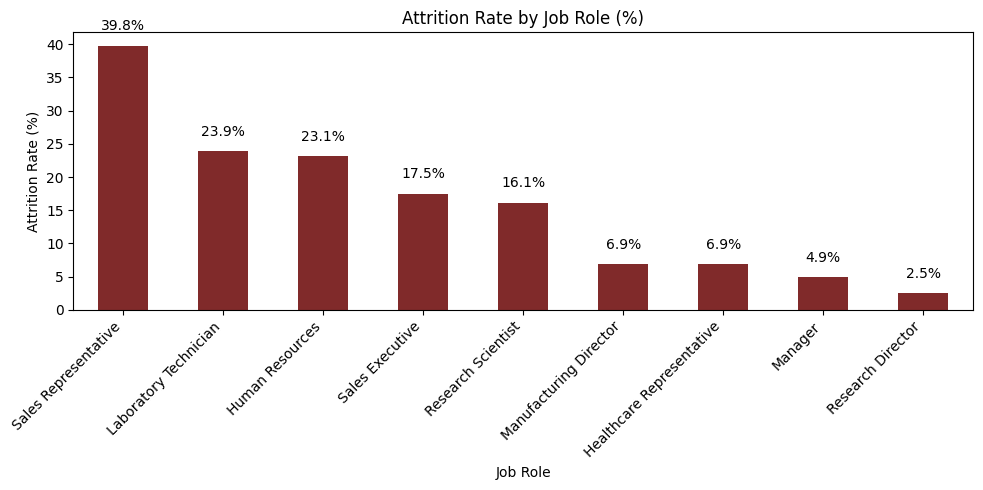

In [32]:
plt.figure(figsize=(10, 5))
ax = job_attrition_yes.plot(kind="bar", color="#802A2A")

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=9)

plt.title("Attrition Rate by Job Role (%)")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [33]:
sales representative has highest attrition in all company (make )

SyntaxError: invalid syntax (811677700.py, line 1)


##  تحليل الرواتب والخبرة والأداء


In [34]:
df['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [35]:
avg_income_byrole=df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
avg_income_byrole #sales representative is least

JobRole
Manager                      17181.676471
Research Director            16033.550000
Healthcare Representative     7528.763359
Manufacturing Director        7295.137931
Sales Executive               6924.279141
Human Resources               4235.750000
Research Scientist            3239.972603
Laboratory Technician         3237.169884
Sales Representative          2626.000000
Name: MonthlyIncome, dtype: float64

In [36]:
corr_income_exp = df['MonthlyIncome'].corr(df['TotalWorkingYears'])
corr_income_exp.round(2)  # strong relation

np.float64(0.77)

In [37]:
perf_by_dept = df.groupby('Department')['PerformanceRating'].mean()
perf_by_dept # sales least

Department
Human Resources           3.142857
Research & Development    3.162331
Sales                     3.136771
Name: PerformanceRating, dtype: float64

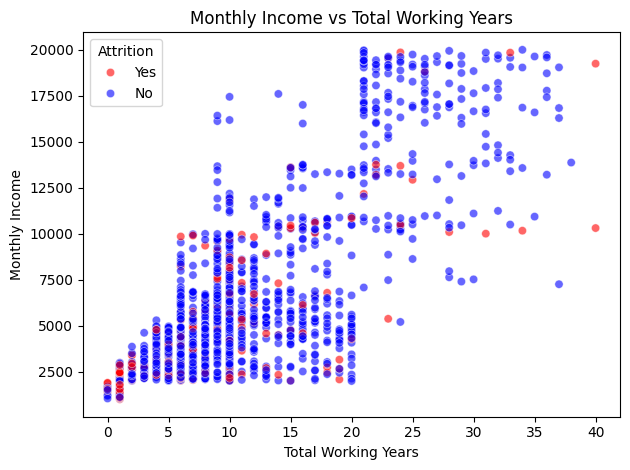

In [38]:
plt.figure()
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome',
                 hue='Attrition', alpha=0.6, palette={'Yes': 'red', 'No': 'blue'})
plt.title('Monthly Income vs Total Working Years')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

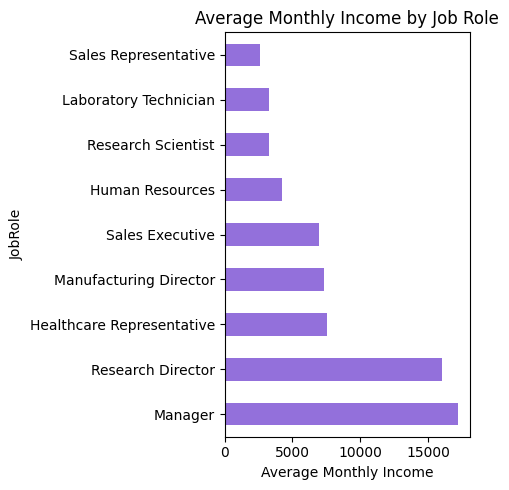

In [39]:
plt.figure(figsize=(5, 5))
avg_income_byrole.plot(kind='barh', color='mediumpurple')
plt.xlabel('Average Monthly Income')
plt.title('Average Monthly Income by Job Role')
plt.tight_layout()
plt.show() # sales representative least


##  تحليل مستوى رضا الموظفين


In [40]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction','RelationshipSatisfaction', 'WorkLifeBalance']
df[satisfaction_cols].mean().round(2)


JobSatisfaction             2.73
EnvironmentSatisfaction     2.72
RelationshipSatisfaction    2.71
WorkLifeBalance             2.76
dtype: float64

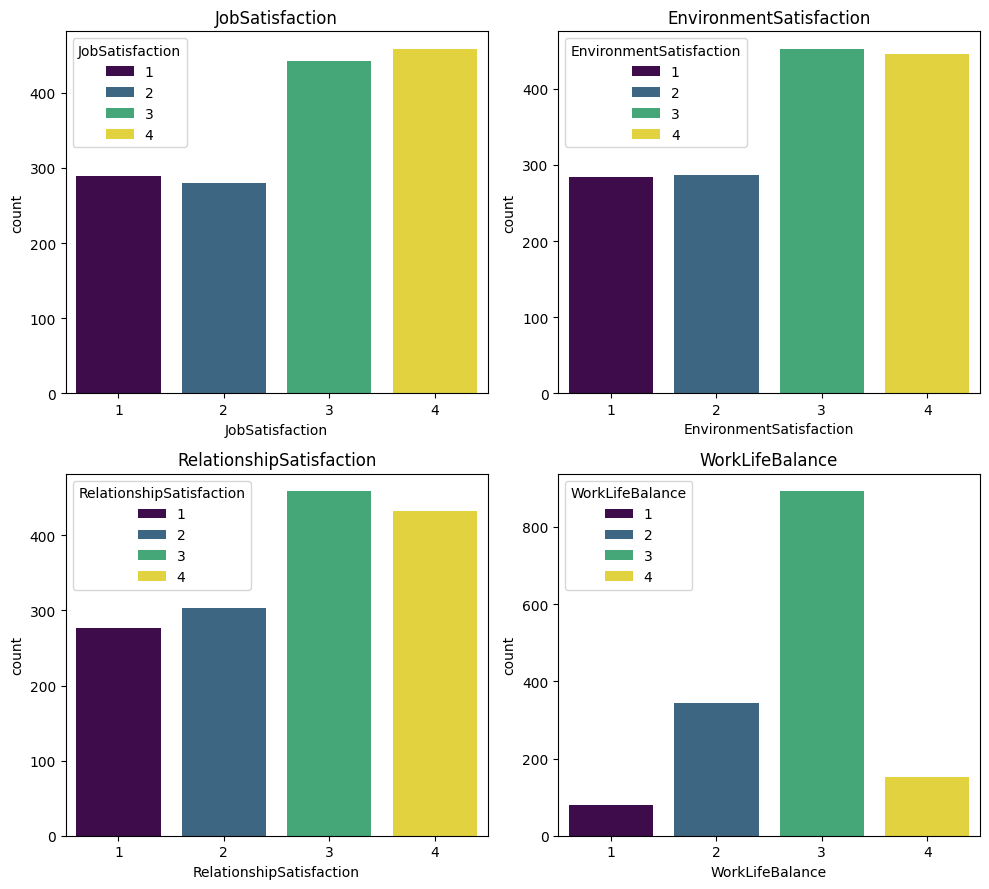

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, col in zip(axes.flatten(), satisfaction_cols):
    sns.countplot(data=df, x=col, ax=ax, palette='viridis',hue=col)
    ax.set_title(col)
plt.tight_layout()
plt.show()


##  تحليل Attrition والعوامل المرتبطة بيه


In [54]:
attr_overtime = (df['Attrition'] == 'Yes').groupby(df['OverTime']).mean() * 100
attr_overtime.round(1)

OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64

In [55]:
attr_jobsat = (df['Attrition'] == 'Yes').groupby(df['JobSatisfaction']).mean() * 100
attr_jobsat.round(1)

JobSatisfaction
1    22.8
2    16.4
3    16.5
4    11.3
Name: Attrition, dtype: float64

In [56]:
attr_worklife = (df['Attrition'] == 'Yes').groupby(df['WorkLifeBalance']).mean() * 100
attr_worklife.round(1)

WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: Attrition, dtype: float64

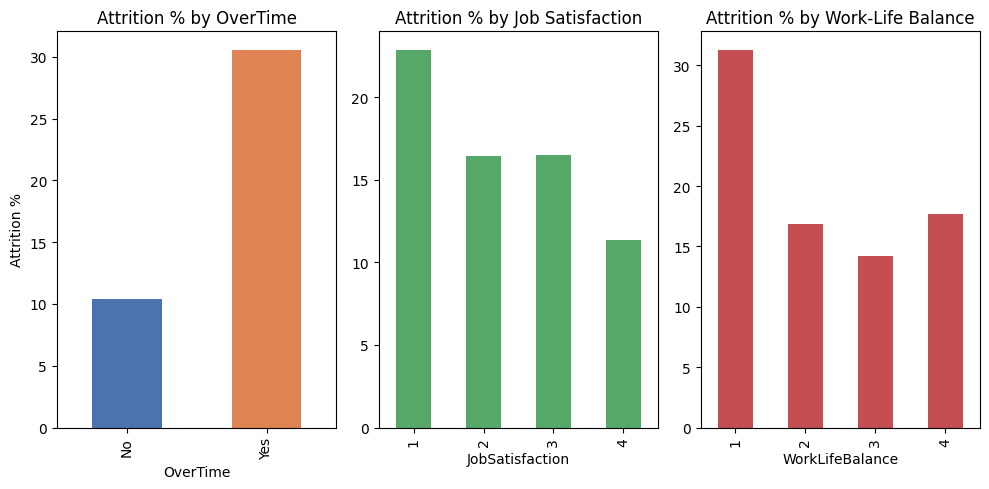

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

attr_overtime.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Attrition % by OverTime')
axes[0].set_ylabel('Attrition %')

attr_jobsat.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Attrition % by Job Satisfaction')

attr_worklife.plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Attrition % by Work-Life Balance')

plt.tight_layout()
plt.show()

## ---- Visualization 8: Heatmap للارتباطات بين أهم المتغيرات ----

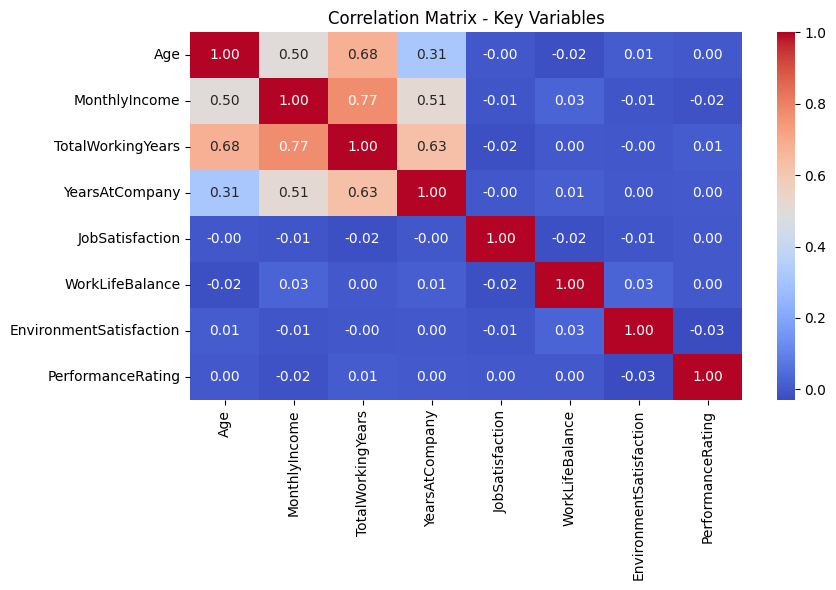

In [61]:
corr_cols1 = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
             'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
             'PerformanceRating', 'AttritionFlag']
existing_cols = [col for col in corr_cols1 if col in df.columns]

plt.figure(figsize=(9, 6))
sns.heatmap(df[existing_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - Key Variables')
plt.tight_layout()
plt.show()
